# **Data Uploading**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/FatemaTaher/Cairo_University_Hackathon/main/clean_data.csv"

df = pd.read_csv(url)

df

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Product Key
0,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,PROD-00013
1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,PROD-00057
2,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,PROD-00960
3,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,PROD-00328
4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,PROD-01338
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,CA-2017-125920,2017-05-21,2017-05-28,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980,PROD-00785
9796,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680,PROD-00526
9797,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880,PROD-01893
9798,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760,PROD-01734


# **Data Preprocessing**

## **Sort by Order Date**

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df = df.sort_values(by='Order Date')
df.tail(5)

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Product Key
1297,CA-2018-115427,2018-12-30,2019-01-03,Standard Class,EB-13975,Erica Bern,Corporate,United States,Fairfield,California,94533,West,OFF-BI-10004632,Office Supplies,Binders,GBC Binding covers,20.720,PROD-00844
906,CA-2018-143259,2018-12-30,2019-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,New York,10009,East,FUR-BO-10003441,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Fully Ass...",323.136,PROD-00033
645,CA-2018-126221,2018-12-30,2019-01-05,Standard Class,CC-12430,Chuck Clark,Home Office,United States,Columbus,Indiana,47201,Central,OFF-AP-10002457,Office Supplies,Appliances,Eureka The Boss Plus 12-Amp Hard Box Upright V...,209.300,PROD-00435
908,CA-2018-143259,2018-12-30,2019-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,New York,10009,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,52.776,PROD-00796
5091,CA-2018-156720,2018-12-30,2019-01-03,Standard Class,JM-15580,Jill Matthias,Consumer,United States,Loveland,Colorado,80538,West,OFF-FA-10003472,Office Supplies,Fasteners,Bagged Rubber Bands,3.024,PROD-00948


## **Data Info**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9800 entries, 7980 to 5091
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       9800 non-null   object        
 1   Order Date     9800 non-null   datetime64[ns]
 2   Ship Date      9800 non-null   object        
 3   Ship Mode      9800 non-null   object        
 4   Customer ID    9800 non-null   object        
 5   Customer Name  9800 non-null   object        
 6   Segment        9800 non-null   object        
 7   Country        9800 non-null   object        
 8   City           9800 non-null   object        
 9   State          9800 non-null   object        
 10  Postal Code    9800 non-null   object        
 11  Region         9800 non-null   object        
 12  Product ID     9800 non-null   object        
 13  Category       9800 non-null   object        
 14  Sub-Category   9800 non-null   object        
 15  Product Name   9800 non

### **Columns Type: Ship Date**

In [ ]:
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days
df['Delayed'] = (df['Shipping Days'] > 5).astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9800 entries, 7980 to 5091
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       9800 non-null   object        
 1   Order Date     9800 non-null   datetime64[ns]
 2   Ship Date      9800 non-null   datetime64[ns]
 3   Ship Mode      9800 non-null   object        
 4   Customer ID    9800 non-null   object        
 5   Customer Name  9800 non-null   object        
 6   Segment        9800 non-null   object        
 7   Country        9800 non-null   object        
 8   City           9800 non-null   object        
 9   State          9800 non-null   object        
 10  Postal Code    9800 non-null   object        
 11  Region         9800 non-null   object        
 12  Product ID     9800 non-null   object        
 13  Category       9800 non-null   object        
 14  Sub-Category   9800 non-null   object        
 15  Product Name   9800 non

In [ ]:
df['Delayed'].value_counts()

,count
Delayed,
0,8015
1,1785


In [ ]:

monthly = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
print(f"Months: {len(monthly)}")

print(f"Customers: {df['Customer ID'].nunique()}")


Months: 48
Customers: 793


# **Shipping Delay Prediction (Classification)**

## **Setups**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


## **Create Target**

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days
df['Delayed'] = (df['Shipping Days'] > 5).astype(int)

print("Class Distribution:")
print(df['Delayed'].value_counts())
print(df['Delayed'].value_counts(normalize=True).round(3))

Class Distribution:
Delayed
0    8015
1    1785
Name: count, dtype: int64
Delayed
0    0.818
1    0.182
Name: proportion, dtype: float64


## **Feature Engineering** Using Cyclic Encoding

In [ ]:

df['Order Month']     = df['Order Date'].dt.month
df['Order Year']      = df['Order Date'].dt.year
df['Order Quarter']   = df['Order Date'].dt.quarter
df['Order DayOfWeek'] = df['Order Date'].dt.dayofweek

# Cyclic Encoding
def cyclic_encode(df, col, max_val):

    df[f'{col}_sin'] = np.sin(2 * np.pi * df[col] / max_val)
    df[f'{col}_cos'] = np.cos(2 * np.pi * df[col] / max_val)
    return df

df = cyclic_encode(df, 'Order Month',     max_val=12)
df = cyclic_encode(df, 'Order DayOfWeek', max_val=7)
df = cyclic_encode(df, 'Order Quarter',   max_val=4)

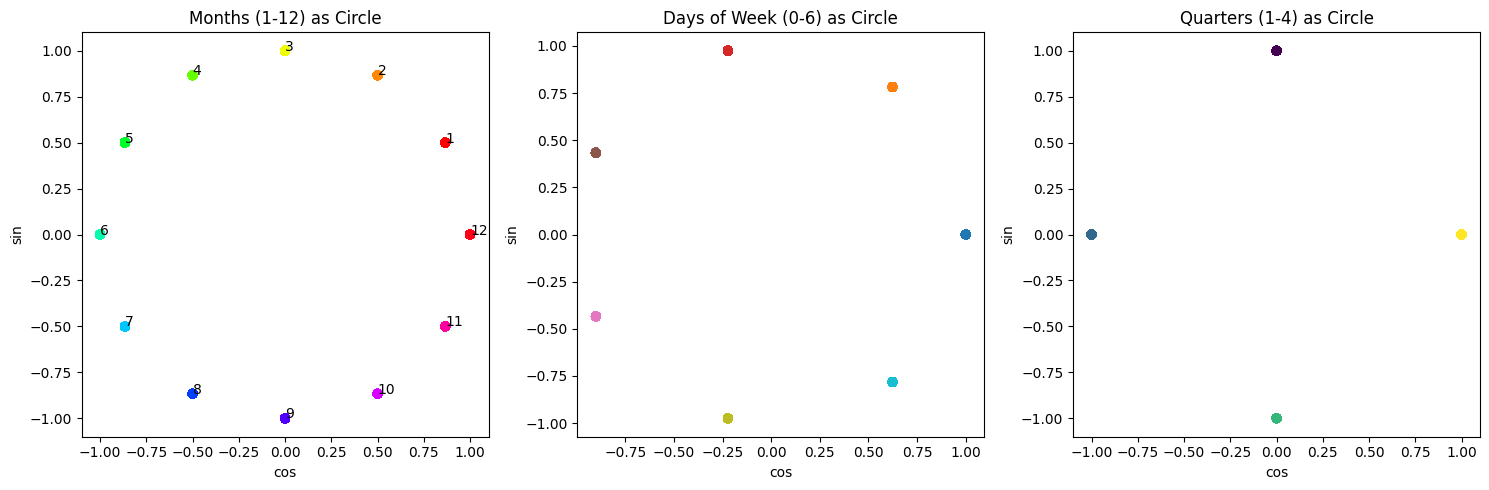

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(df['Order Month_cos'], df['Order Month_sin'], c=df['Order Month'], cmap='hsv')
axes[0].set_title('Months (1-12) as Circle')
axes[0].set_xlabel('cos')
axes[0].set_ylabel('sin')
for i in range(1, 13):
    mask = df['Order Month'] == i
    if mask.any():
        axes[0].annotate(str(i),
                        (df.loc[mask, 'Order Month_cos'].iloc[0],
                         df.loc[mask, 'Order Month_sin'].iloc[0]))

axes[1].scatter(df['Order DayOfWeek_cos'], df['Order DayOfWeek_sin'], c=df['Order DayOfWeek'], cmap='tab10')
axes[1].set_title('Days of Week (0-6) as Circle')
axes[1].set_xlabel('cos')
axes[1].set_ylabel('sin')

axes[2].scatter(df['Order Quarter_cos'], df['Order Quarter_sin'], c=df['Order Quarter'], cmap='viridis')
axes[2].set_title('Quarters (1-4) as Circle')
axes[2].set_xlabel('cos')
axes[2].set_ylabel('sin')

plt.tight_layout()
plt.show()

## **Features**

In [ ]:

features = [
    'Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category',
    'Order Month_sin', 'Order Month_cos',
    'Order DayOfWeek_sin', 'Order DayOfWeek_cos',
    'Order Quarter_sin', 'Order Quarter_cos',
    'Order Year', 'Sales'
]
target = 'Delayed'

X = df[features].copy()
y = df[target].copy()

## **Label Encoding**

In [ ]:
cat_cols = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))

print("\nFeatures after Cyclic Encoding:")
print(X.head())


Features after Cyclic Encoding:
   Ship Mode  Segment  Region  Category  Sub-Category  Order Month_sin  \
0          2        0       2         0             4    -5.000000e-01   
1          2        0       2         0             5    -5.000000e-01   
2          2        1       3         1            10     1.224647e-16   
3          3        0       2         0            16    -8.660254e-01   
4          3        0       2         1            14    -8.660254e-01   

   Order Month_cos  Order DayOfWeek_sin  Order DayOfWeek_cos  \
0         0.866025             0.974928            -0.222521   
1         0.866025             0.974928            -0.222521   
2        -1.000000             0.000000             1.000000   
3         0.500000             0.781831             0.623490   
4         0.500000             0.781831             0.623490   

   Order Quarter_sin  Order Quarter_cos  Order Year     Sales  
0      -2.449294e-16                1.0        2017  261.9600  
1      -2

## **Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

## **Scale Pos Weight**

In [ ]:
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nscale_pos_weight = {scale:.2f}")



scale_pos_weight = 4.49


## **Models**

In [ ]:
models = {
    'XGBoost': XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        scale_pos_weight=scale, random_state=42, verbosity=0, eval_metric='logloss'
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300, learning_rate=0.05,
        class_weight='balanced', random_state=42, verbose=-1
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42
    ),
}


## **Train & Evaluate**

In [ ]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    auc   = roc_auc_score(y_test, proba)
    results[name] = {'AUC': auc, 'model': model, 'proba': proba}
    print(f"\n{'='*40}")
    print(f"  {name} | AUC = {auc:.4f}")
    print(classification_report(y_test, preds, target_names=['On Time', 'Delayed']))


  XGBoost | AUC = 0.8121
              precision    recall  f1-score   support

     On Time       0.93      0.70      0.80      1603
     Delayed       0.36      0.76      0.49       357

    accuracy                           0.71      1960
   macro avg       0.65      0.73      0.65      1960
weighted avg       0.83      0.71      0.74      1960


  LightGBM | AUC = 0.8146
              precision    recall  f1-score   support

     On Time       0.92      0.72      0.81      1603
     Delayed       0.37      0.74      0.49       357

    accuracy                           0.72      1960
   macro avg       0.65      0.73      0.65      1960
weighted avg       0.82      0.72      0.75      1960


  Random Forest | AUC = 0.8507
              precision    recall  f1-score   support

     On Time       0.85      0.98      0.91      1603
     Delayed       0.67      0.23      0.35       357

    accuracy                           0.84      1960
   macro avg       0.76      0.60      0.63

## **Stacking**

In [ ]:
estimators = [
    ('xgb', XGBClassifier(n_estimators=200, scale_pos_weight=scale,
                           random_state=42, verbosity=0, eval_metric='logloss')),
    ('lgb', LGBMClassifier(n_estimators=200, class_weight='balanced',
                            random_state=42, verbose=-1)),
    ('rf',  RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)),
]
stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(class_weight='balanced'),
    cv=5, passthrough=False
)
stacking.fit(X_train, y_train)
stack_preds = stacking.predict(X_test)
stack_proba = stacking.predict_proba(X_test)[:, 1]
stack_auc   = roc_auc_score(y_test, stack_proba)
results['Stacking'] = {'AUC': stack_auc, 'proba': stack_proba}
print(f"\nStacking | AUC = {stack_auc:.4f}")
print(classification_report(y_test, stack_preds, target_names=['On Time', 'Delayed']))


Stacking | AUC = 0.8384
              precision    recall  f1-score   support

     On Time       0.94      0.71      0.81      1603
     Delayed       0.38      0.79      0.51       357

    accuracy                           0.73      1960
   macro avg       0.66      0.75      0.66      1960
weighted avg       0.84      0.73      0.76      1960



## **ROC Curves**

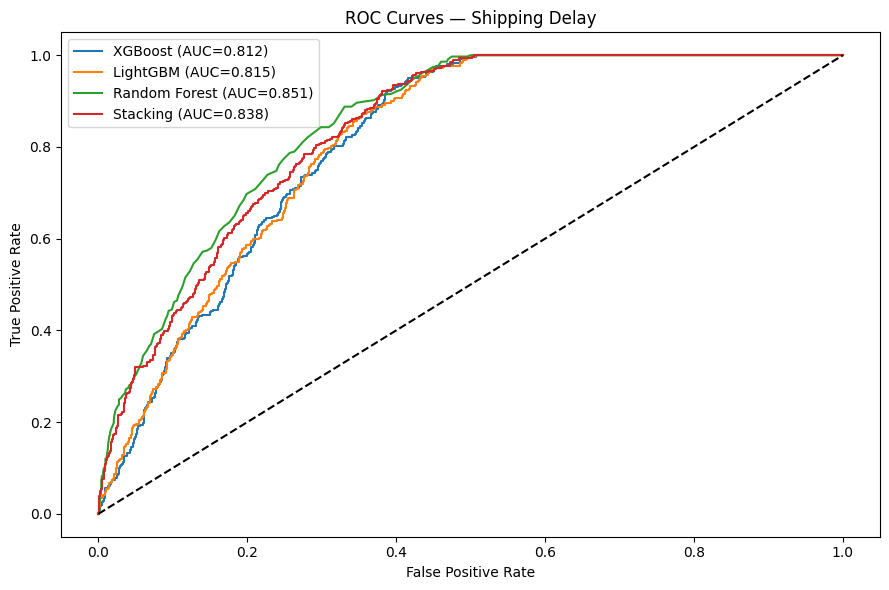

In [ ]:
plt.figure(figsize=(9, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['AUC']:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Shipping Delay')
plt.legend()
plt.tight_layout()
plt.show()

## **Confusion Matrix (Best Model)**

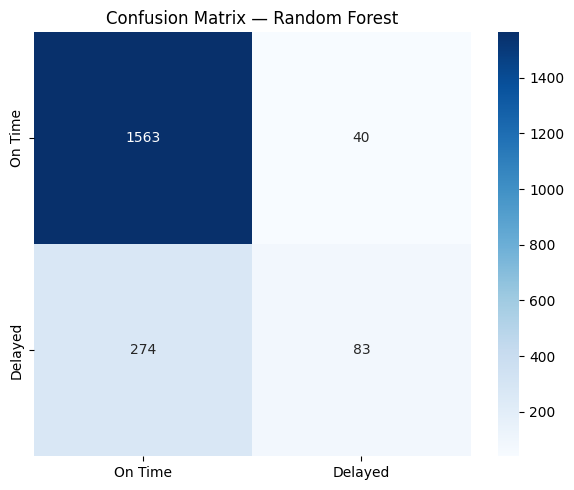

In [ ]:

best_name = max(results, key=lambda x: results[x]['AUC'])
best_preds = stacking.predict(X_test) if best_name == 'Stacking' else models[best_name].predict(X_test)
cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['On Time','Delayed'],
            yticklabels=['On Time','Delayed'])
plt.title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.show()

# **Sales Forecasting (Time Series)**

In [ ]:
!pip install prophet --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

## **Load Data**

In [ ]:
url = "https://raw.githubusercontent.com/FatemaTaher/Cairo_University_Hackathon/main/clean_data.csv"
df = pd.read_csv(url)
df['Order Date'] = pd.to_datetime(df['Order Date'])

## **Monthly Aggregation**

In [ ]:
monthly = (
    df.groupby(df['Order Date'].dt.to_period('M'))['Sales']
    .sum()
    .reset_index()
)
monthly.columns = ['Month', 'Sales']
monthly['Month'] = monthly['Month'].dt.to_timestamp()
print(monthly.head())
print(f"\nTotal months: {len(monthly)}")


       Month      Sales
0 2015-01-01  14205.707
1 2015-02-01   4519.892
2 2015-03-01  55205.797
3 2015-04-01  27906.855
4 2015-05-01  23644.303

Total months: 48


## **Plot Monthly Sales**

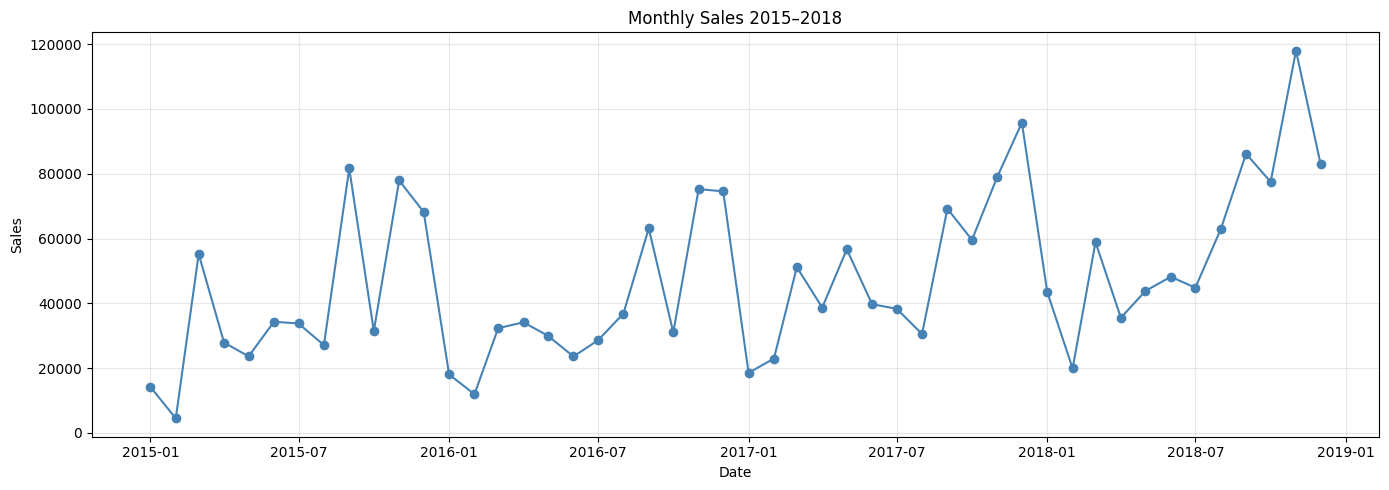

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(monthly['Month'], monthly['Sales'], marker='o', color='steelblue')
plt.title('Monthly Sales 2015–2018')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## **Train/Test Split (last 6 months = test)**

In [ ]:
train = monthly[:-6]
test  = monthly[-6:]


## **MODEL A: PROPHET**

In [ ]:
prophet_train = train.rename(columns={'Month': 'ds', 'Sales': 'y'})
prophet_test  = test.rename(columns={'Month': 'ds', 'Sales': 'y'})

m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)
m.fit(prophet_train)

future   = m.make_future_dataframe(periods=12, freq='MS')
forecast = m.predict(future)

## **Plot**

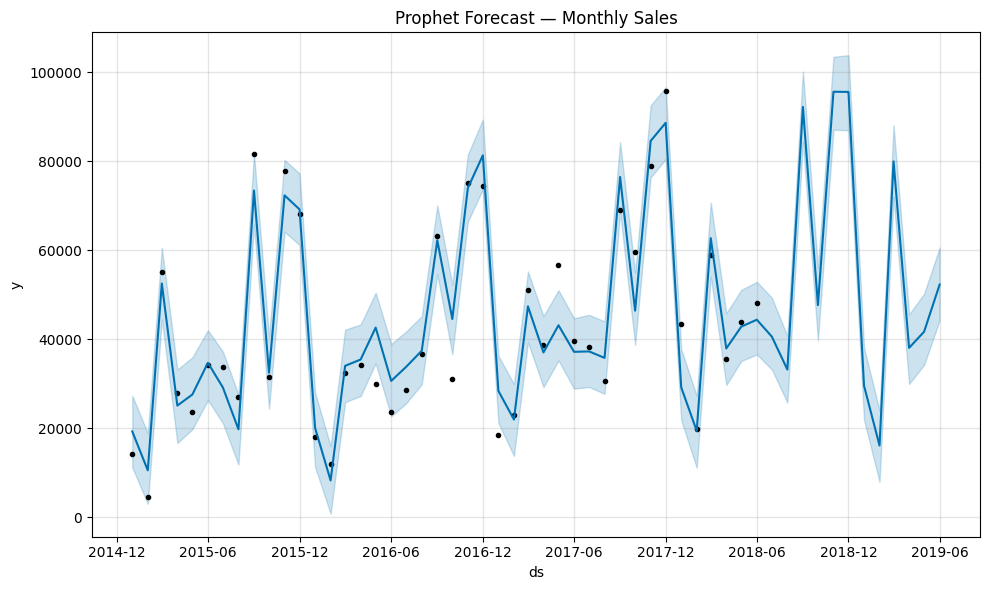

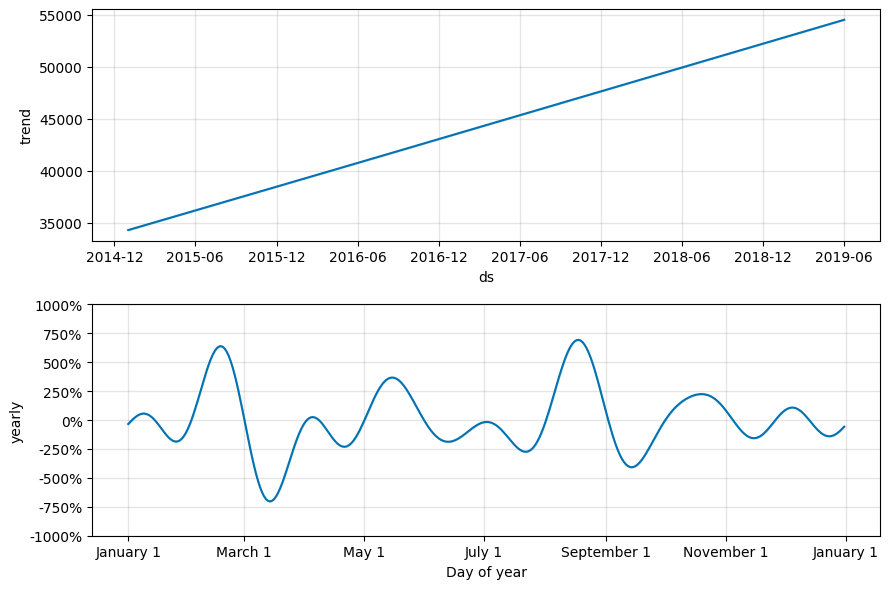

In [ ]:
fig = m.plot(forecast)
plt.title('Prophet Forecast — Monthly Sales')
plt.tight_layout()
plt.show()

fig2 = m.plot_components(forecast)
plt.tight_layout()
plt.show()


## **Evaluate on test**

In [ ]:
prophet_pred = forecast[forecast['ds'].isin(prophet_test['ds'])]['yhat'].values
prophet_mae  = mean_absolute_error(prophet_test['y'], prophet_pred)
prophet_rmse = mean_squared_error(prophet_test['y'], prophet_pred) ** 0.5
print(f"\nProphet | MAE={prophet_mae:.2f} | RMSE={prophet_rmse:.2f}")


Prophet | MAE=17421.14 | RMSE=20294.61


## **MODEL B: XGBoost Time Series**

In [ ]:
def make_lag_features(series, lags=6):
    df_ts = pd.DataFrame({'y': series.values}, index=series.index)
    for lag in range(1, lags+1):
        df_ts[f'lag_{lag}'] = df_ts['y'].shift(lag)
    df_ts['month']   = df_ts.index.month
    df_ts['quarter'] = df_ts.index.quarter
    df_ts['year']    = df_ts.index.year
    return df_ts.dropna()

ts = monthly.set_index('Month')['Sales']
ts_features = make_lag_features(ts, lags=6)

X_ts = ts_features.drop('y', axis=1)
y_ts = ts_features['y']

split = len(X_ts) - 6
X_tr, X_te = X_ts.iloc[:split], X_ts.iloc[split:]
y_tr, y_te = y_ts.iloc[:split], y_ts.iloc[split:]

xgb_ts = XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42, verbosity=0)
xgb_ts.fit(X_tr, y_tr)
xgb_preds = xgb_ts.predict(X_te)

xgb_mae  = mean_absolute_error(y_te, xgb_preds)
xgb_rmse = mean_squared_error(y_te, xgb_preds) ** 0.5
print(f"XGBoost TS | MAE={xgb_mae:.2f} | RMSE={xgb_rmse:.2f}")

XGBoost TS | MAE=25952.50 | RMSE=29865.19


## **Comparison Plot**

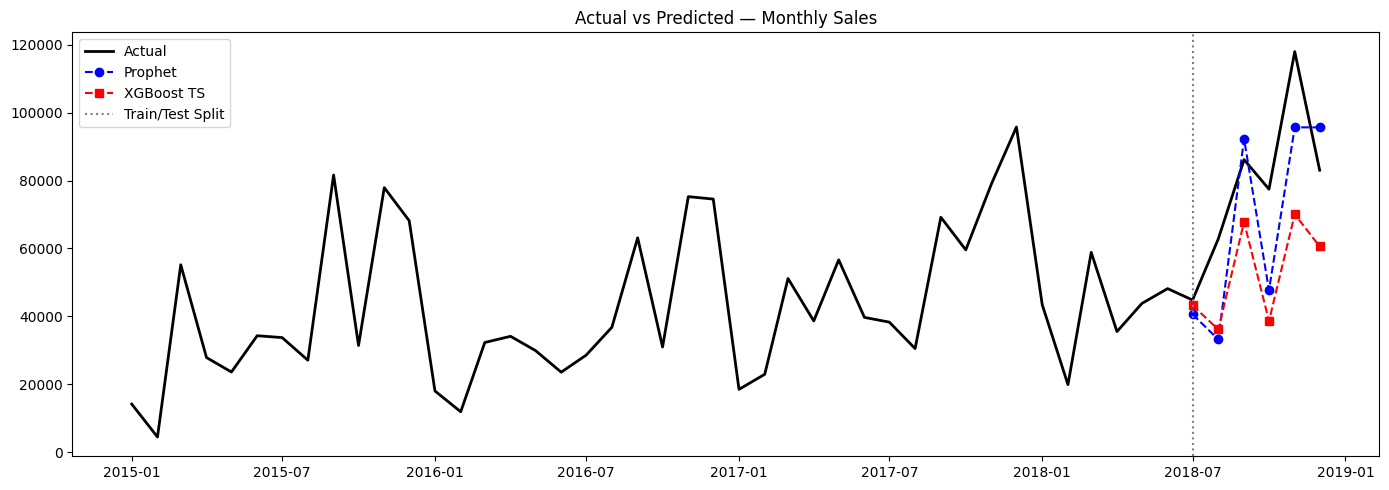

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(monthly['Month'], monthly['Sales'], label='Actual', color='black', linewidth=2)
plt.plot(test['Month'], prophet_pred, label='Prophet', color='blue', linestyle='--', marker='o')
plt.plot(y_te.index, xgb_preds, label='XGBoost TS', color='red', linestyle='--', marker='s')
plt.axvline(test['Month'].iloc[0], color='gray', linestyle=':', label='Train/Test Split')
plt.title('Actual vs Predicted — Monthly Sales')
plt.legend()
plt.tight_layout()
plt.show()


## **Category Forecast**


Category-Level Forecasting


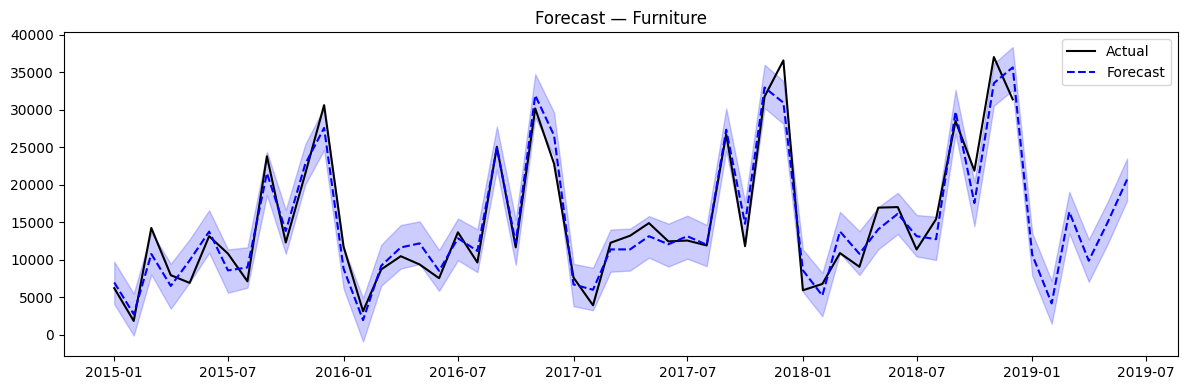

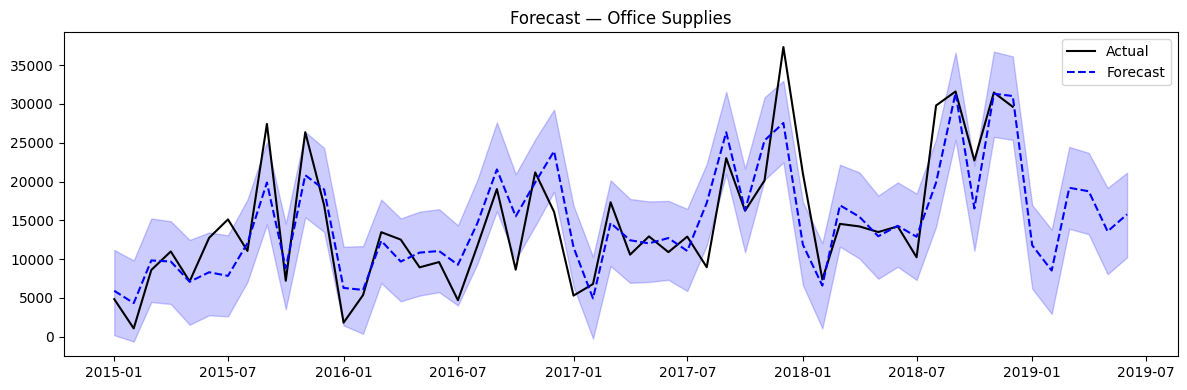

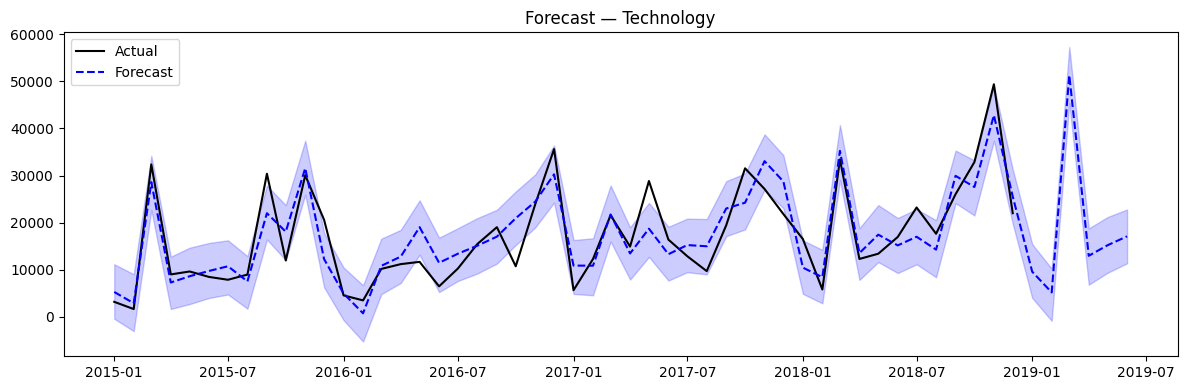

In [ ]:

print("\nCategory-Level Forecasting")
for cat in df['Category'].unique():
    cat_df = df[df['Category'] == cat]
    cat_monthly = (
        cat_df.groupby(df['Order Date'].dt.to_period('M'))['Sales']
        .sum().reset_index()
    )
    cat_monthly.columns = ['ds', 'y']
    cat_monthly['ds'] = cat_monthly['ds'].dt.to_timestamp()

    m_cat = Prophet(yearly_seasonality=True, seasonality_mode='multiplicative',
                    weekly_seasonality=False, daily_seasonality=False)
    m_cat.fit(cat_monthly)
    future_cat = m_cat.make_future_dataframe(periods=6, freq='MS')
    fc_cat = m_cat.predict(future_cat)

    plt.figure(figsize=(12, 4))
    plt.plot(cat_monthly['ds'], cat_monthly['y'], label='Actual', color='black')
    plt.plot(fc_cat['ds'], fc_cat['yhat'], label='Forecast', color='blue', linestyle='--')
    plt.fill_between(fc_cat['ds'], fc_cat['yhat_lower'], fc_cat['yhat_upper'],
                     alpha=0.2, color='blue')
    plt.title(f'Forecast — {cat}')
    plt.legend()
    plt.tight_layout()
    plt.show()

# **Customer Segmentation (Clustering)**

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

url = "https://raw.githubusercontent.com/FatemaTaher/Cairo_University_Hackathon/main/clean_data.csv"
df = pd.read_csv(url)
df['Order Date'] = pd.to_datetime(df['Order Date'])


## **RFM Feature Engineering**


In [ ]:
snapshot_date = df['Order Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency   = ('Order Date', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Order ID',   'nunique'),
    Monetary  = ('Sales',      'sum'),
    AvgOrder  = ('Sales',      'mean'),
    NumStates = ('State',      'nunique'),
).reset_index()

print("RFM Sample:")
print(rfm.head())
print(f"\nShape: {rfm.shape}")

RFM Sample:
  Customer ID  Recency  Frequency  Monetary    AvgOrder  NumStates
0    AA-10315      185          5  5563.560  505.778182          4
1    AA-10375       20          9  1056.390   70.426000          8
2    AA-10480      260          4  1790.512  149.209333          4
3    AA-10645       56          6  5086.935  282.607500          5
4    AB-10015      416          3   886.156  147.692667          3

Shape: (793, 6)


## **Distribution Plots**

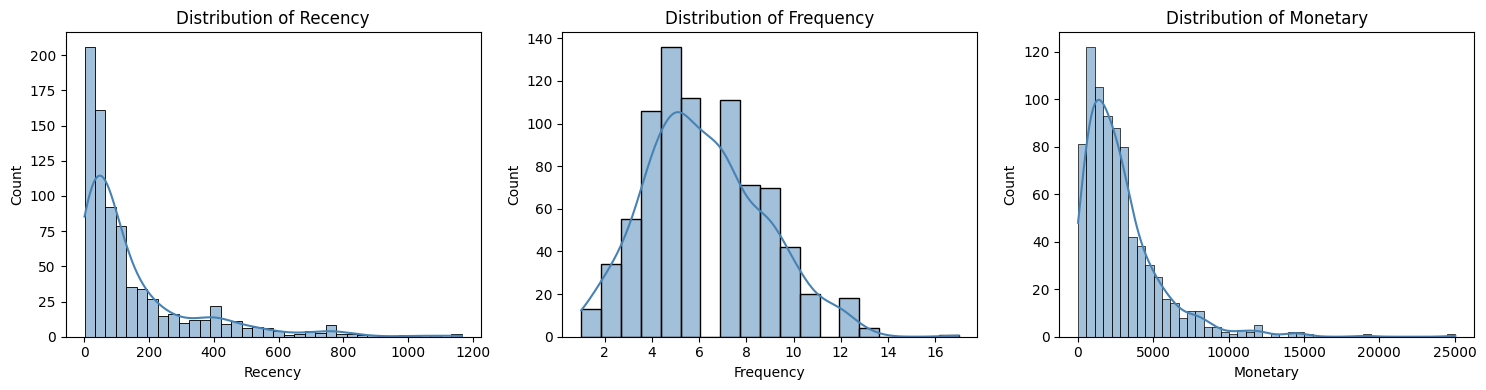

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    sns.histplot(rfm[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

## **Scale**

In [ ]:
features_rfm = ['Recency', 'Frequency', 'Monetary', 'AvgOrder', 'NumStates']
scaler = StandardScaler()
X_rfm  = scaler.fit_transform(rfm[features_rfm])

## **Elbow Method**

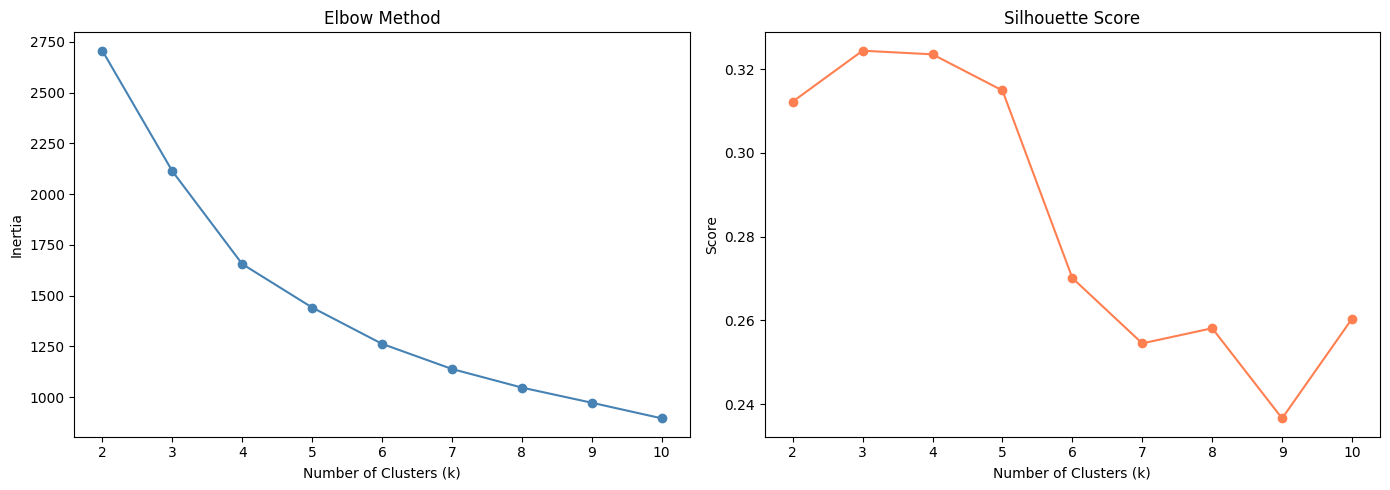


Best K = 3 (Silhouette = 0.3244)


In [ ]:
inertias   = []
sil_scores = []
k_range    = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_rfm)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_rfm, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_range, inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, sil_scores, marker='o', color='coral')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Score')
plt.tight_layout()
plt.show()

best_k = k_range[np.argmax(sil_scores)]
print(f"\nBest K = {best_k} (Silhouette = {max(sil_scores):.4f})")

## **Final KMeans**

In [ ]:
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(X_rfm)

## **Cluster Analysis**



In [ ]:
cluster_summary = rfm.groupby('Cluster')[features_rfm].mean().round(2)
print(cluster_summary)


         Recency  Frequency  Monetary  AvgOrder  NumStates
Cluster                                                   
0         145.27       6.49   8757.30    678.02       5.11
1         213.04       4.36   1475.41    174.43       3.68
2          72.77       8.39   3392.91    205.60       6.70


## **Label Clusters**

In [ ]:
cluster_labels = {}
sorted_by_value = rfm.groupby('Cluster')['Monetary'].mean().sort_values(ascending=False)
label_map = ['VIP 💎', 'High Value ⭐', 'Regular 🟡', 'Inactive ❌']
for i, (cluster_id, _) in enumerate(sorted_by_value.items()):
    cluster_labels[cluster_id] = label_map[i] if i < len(label_map) else f'Segment {i}'

rfm['Segment Label'] = rfm['Cluster'].map(cluster_labels)
print("\nSegment Distribution:")
print(rfm['Segment Label'].value_counts())


Segment Distribution:
Segment Label
Regular 🟡       400
High Value ⭐    330
VIP 💎            63
Name: count, dtype: int64


## **PCA Visualization**

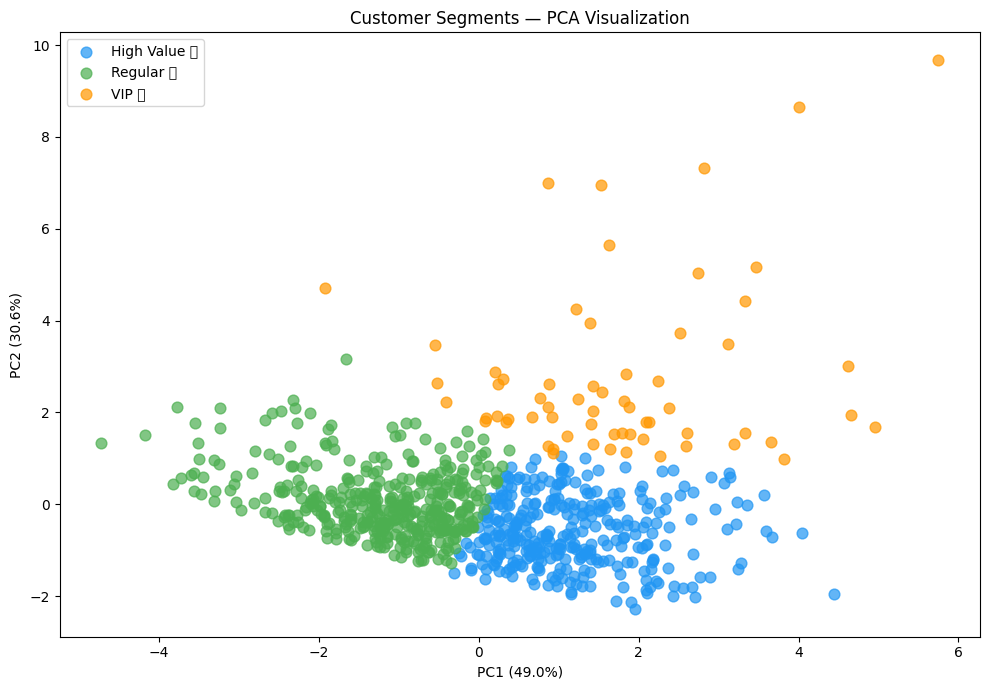

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_rfm)
rfm['PCA1'] = X_pca[:, 0]
rfm['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 7))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']
for i, (label, group) in enumerate(rfm.groupby('Segment Label')):
    plt.scatter(group['PCA1'], group['PCA2'],
                label=label, alpha=0.7, s=60, color=colors[i % len(colors)])
plt.title('Customer Segments — PCA Visualization')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend()
plt.tight_layout()
plt.show()

## **Radar Chart per Segment**

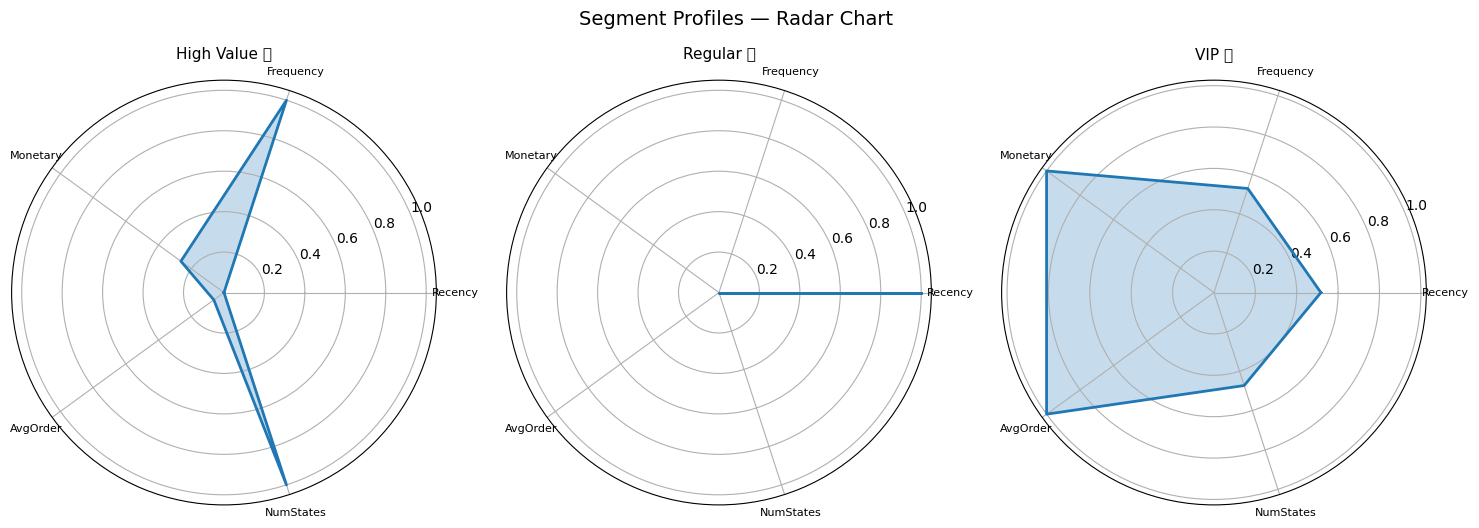

In [ ]:
from matplotlib.patches import FancyBboxPatch

seg_means = rfm.groupby('Segment Label')[features_rfm].mean()
seg_norm  = (seg_means - seg_means.min()) / (seg_means.max() - seg_means.min())

categories = features_rfm
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(1, len(seg_norm), figsize=(5*len(seg_norm), 5),
                          subplot_kw=dict(polar=True))
if len(seg_norm) == 1:
    axes = [axes]

for ax, (seg, row) in zip(axes, seg_norm.iterrows()):
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=8)
    ax.set_title(seg, size=11, pad=15)

plt.suptitle('Segment Profiles — Radar Chart', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## **Business Insights**

In [ ]:
print("\nBusiness Insights:")
for label, group in rfm.groupby('Segment Label'):
    avg_monetary = group['Monetary'].mean()
    avg_recency  = group['Recency'].mean()
    count        = len(group)
    print(f"\n{label}:")
    print(f"  Count={count} | Avg Revenue=${avg_monetary:,.0f} | Avg Recency={avg_recency:.0f} days")


Business Insights:

High Value ⭐:
  Count=330 | Avg Revenue=$3,393 | Avg Recency=73 days

Regular 🟡:
  Count=400 | Avg Revenue=$1,475 | Avg Recency=213 days

VIP 💎:
  Count=63 | Avg Revenue=$8,757 | Avg Recency=145 days
